In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
from bin.criterions import *
np.seterr(all = 'ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
df_q = pd.read_csv("../src/quaterly_train.csv", index_col=0)
df_d = pd.read_csv("../src/daily_train.csv", index_col=0)
df_h = pd.read_csv("../src/hourly_train.csv", index_col=0)
df_m = pd.read_csv('../src/monthly_train.csv', index_col=0)
df_w = pd.read_csv("../src/weekly_train.csv", index_col=0)
df_y = pd.read_csv("../src/yearly_train.csv", index_col=0)

In [3]:
new_test = pd.DataFrame(columns=["equals_res", "chi2_res"])

In [4]:
df_list = [df_q,df_d,df_h,df_m,df_w,df_y]
for df in df_list:
    for index, row in df.iterrows():
        if int(index[1:]) % 100 == 0:
            print(int(index[1:]))
        ts = row.dropna()
        new_test.loc[index] = [double_equals_test(ts), double_chi2_test(ts, alpha=0.95)]

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
1850

ZeroDivisionError: division by zero

In [6]:
for df in df_list[1:]:
    for index, row in df.iterrows():
        if int(index[1:]) % 100 == 0:
            print(int(index[1:]))
        ts = row.dropna()
        try:
            new_test.loc[index] = [double_equals_test(ts), double_chi2_test(ts, alpha=0.95)]
        except:
            new_test.loc[index] = [None, None]

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
100
200
300
400
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
149

In [57]:
perm_q = pd.read_csv("../src/features/quarterly_features.csv", index_col=0)
perm_q.head()

,index,perm_ent4,mse,mape,sym_test,w_perm_ent4,smape,mase,max_diff,amplitude,...,stat_entropy3,stat_entropy4,stat_entropy5,tran_entropy1,tran_entropy2,tran_entropy3,tran_entropy4,tran_entropy5,shape_ent4,shape_ent5
0,Q1,0.818860,22333.057123,0.017638,True,0.470761,0.017467,0.386888,398.315999,1344.145321,...,3.690413,3.690413,3.690413,1.966157,2.784570,3.548322,4.123239,4.586118,0.912624,0.874807
1,Q2,0.779205,24564.254223,0.018605,True,0.496908,0.018422,0.363980,516.798168,1422.576544,...,3.446439,3.446439,3.446439,2.697682,4.424622,5.569147,6.507722,7.060409,0.880808,0.833024
2,Q3,0.698904,7767.906622,0.008752,True,0.474837,0.008720,0.172401,469.932322,1561.741992,...,3.184375,3.184375,3.184375,2.651720,4.745983,6.124130,6.969372,7.509469,0.852018,0.794392
3,Q4,0.738144,15323.172700,0.010606,True,0.489102,0.010475,0.251886,505.660807,1355.150018,...,0.004963,0.000421,0.000034,1.930209,3.337207,4.712708,6.319447,8.003970,0.843956,0.776418
4,Q5,0.612547,16146.143062,0.084324,True,0.471352,0.088779,0.702161,737.000000,2386.000000,...,2.813308,2.812514,2.798176,2.942084,4.328168,5.195484,5.766628,6.111984,0.765279,0.649374


In [59]:
perm_q.index = perm_q['index']

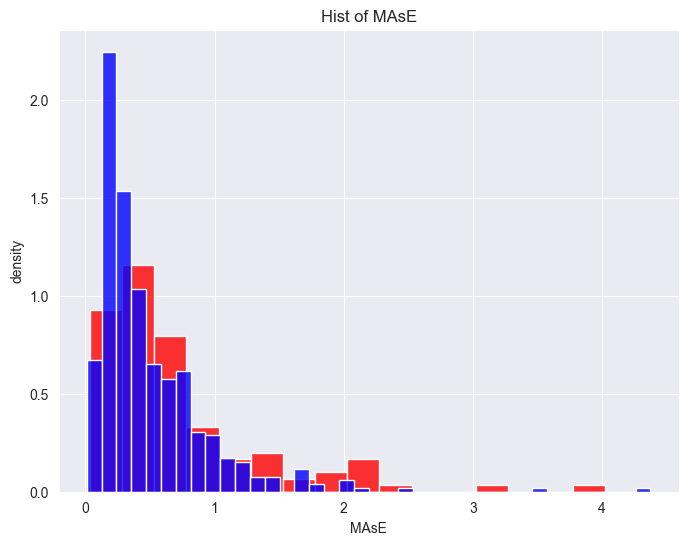

In [61]:
plt.figure(figsize=(8, 6))
sns.histplot(perm_q.loc[new_test1.index][new_test1['equals_res'] == True]['mase'], stat='density', color='red', alpha=0.8)
sns.histplot(perm_q.loc[new_test1.index][new_test1['equals_res'] == False]['mase'], stat='density', color='blue', alpha=0.8)
plt.title('Hist of MAsE')
plt.xlabel('MAsE')
#plt.xlim((0,1))
plt.ylabel('density')
#plt.semilogx()
plt.grid(True)
plt.show()

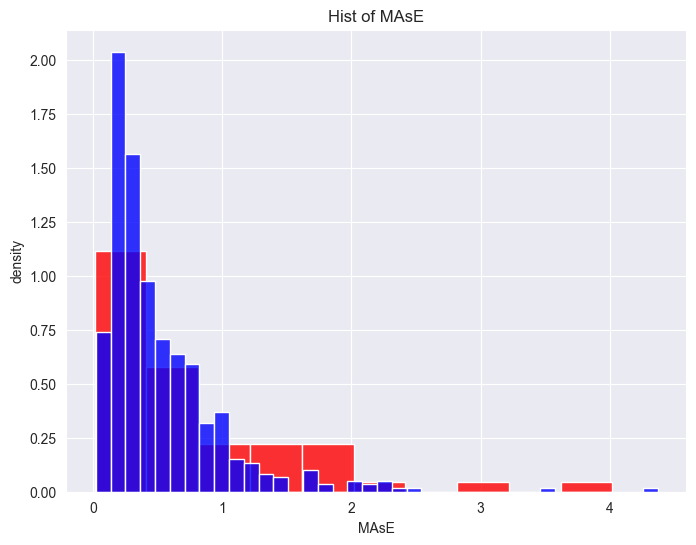

In [64]:
plt.figure(figsize=(8, 6))
sns.histplot(perm_q.loc[new_test1.index][new_test1['chi2_res'] == True]['mase'], stat='density', color='red', alpha=0.8)
sns.histplot(perm_q.loc[new_test1.index][new_test1['chi2_res'] == False]['mase'], stat='density', color='blue', alpha=0.8)
plt.title('Hist of MAsE')
plt.xlabel('MAsE')
plt.ylabel('density')
#plt.semilogx()
#plt.xlim((0,1))
plt.grid(True)
plt.show()

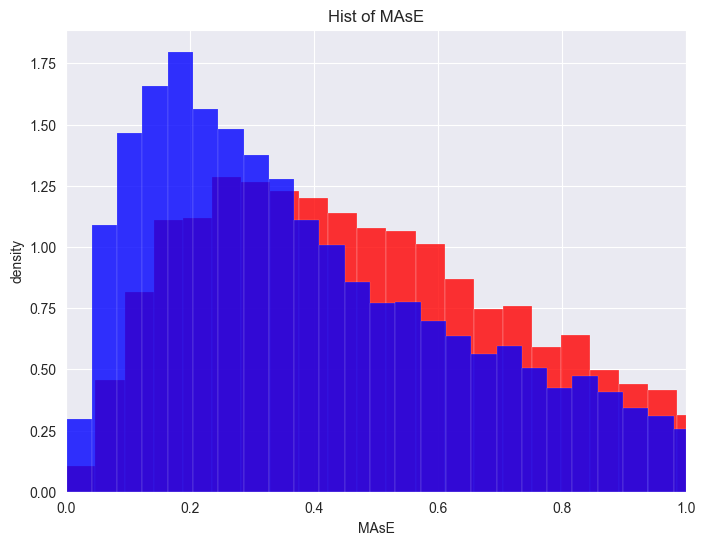

In [29]:
plt.figure(figsize=(8, 6))
sns.histplot(perm_q[(new_test['chi2_res'] == True) & (new_test['equals_res'] == True)]['mase'], stat='density', color='red', alpha=0.8)
sns.histplot(perm_q[(new_test['chi2_res'] == False) | (new_test['equals_res'] == False)]['mase'], stat='density', color='blue', alpha=0.8)
plt.title('Hist of MAsE')
plt.xlabel('MAsE')
plt.ylabel('density')
#plt.semilogx()
plt.xlim((0,1))
plt.grid(True)
plt.show()

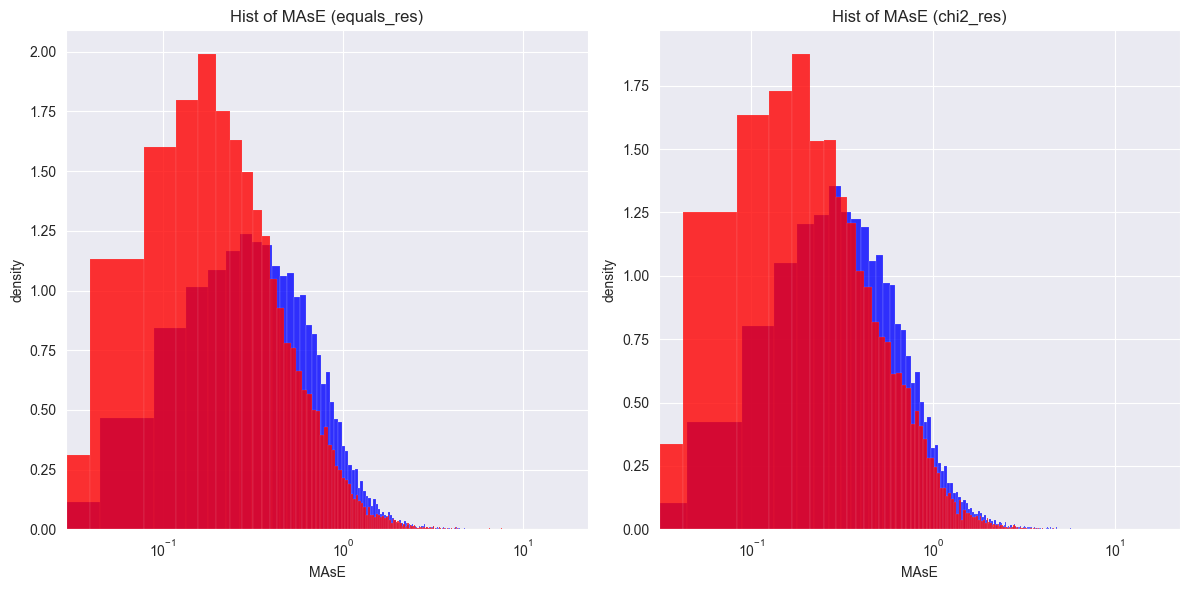

In [126]:
plt.figure(figsize=(12, 6))

# First subplot
plt.subplot(1, 2, 1)
sns.histplot(perm_q[new_test['equals_res']]['mase'], stat='density', color='blue', alpha=0.8)
sns.histplot(perm_q[new_test['equals_res'] == False]['mase'], stat='density', color='red', alpha=0.8)
plt.title('Hist of MAsE (equals_res)')
plt.xlabel('MAsE')
plt.ylabel('density')
plt.semilogx()
plt.grid(True)

# Second subplot
plt.subplot(1, 2, 2)
sns.histplot(perm_q[new_test['chi2_res']]['mase'], stat='density', color='blue', alpha=0.8)
sns.histplot(perm_q[new_test['chi2_res'] == False]['mase'], stat='density', color='red', alpha=0.8)
plt.title('Hist of MAsE (chi2_res)')
plt.xlabel('MAsE')
plt.ylabel('density')
plt.semilogx()
plt.grid(True)

plt.tight_layout()
plt.savefig('double_simmetry_test.png')
plt.show()

In [8]:
new_test.describe()

,equals_res,chi2_res
count,99998,99998
unique,2,2
top,True,False
freq,52856,50659


In [7]:
new_test.to_csv("../src/quater_double_symmetric_test.csv")

In [131]:
perm_q[new_test["equals_res"]][["smape", "mase"]].describe()

,smape,mase
count,12655.000000,12655.000000
mean,0.078384,0.648836
std,0.098315,0.562741
min,0.000000,0.000000
25%,0.020830,0.301006
50%,0.045175,0.521627
75%,0.092919,0.822412
max,1.341650,12.154288


In [11]:
perm_q[new_test["equals_res"] == False][["smape", "mase"]].describe()

NameError: name 'perm_q' is not defined

In [12]:
new_test = pd.read_csv("../src/quater_double_symmetric_test.csv")

In [13]:
new_test

,Unnamed: 0,equals_res,chi2_res
0,Q1,True,True
1,Q2,True,True
2,Q3,True,True
3,Q4,True,True
4,Q5,True,False
...,...,...,...
23995,Q23996,False,False
23996,Q23997,False,False
23997,Q23998,False,False
23998,Q23999,True,False


In [77]:
len_df = []
for index, row in df_m.iterrows():
    if int(index[1:]) % 100 == 0:
        print(int(index[1:]))
    ts = row.dropna()
    len_df.append(len(ts))

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
1850

In [38]:
ts = df_q.iloc[1050].dropna()

In [80]:
sum(pd.Series(len_df) > 500)

1392

In [86]:
aaa = pd.read_csv('../src/metrics&entropy_M4.csv')
aaa[aaa['V1'] == 'H1']

,V1,perm_ent3,perm_ent4,mse,mape,sym_test,w_perm_ent4,smape,mase,max_diff,amplitude,mean,variance,adf_test_pvalue,kpss_test_pvalue,sym_test1,sym_test2,sym_pv,sym_pv1
95359,H1,NaN,0.510222,435.638017,0.023878,True,0.23207,0.023901,0.382901,101.0,577.0,638.488571,24757.803875,0.262292,0.01,True,True,0.751201,0.0626


In [66]:
df_y.shape

(23000, 835)

In [68]:
df_y.to_csv("../src/yearly_train.csv")

In [69]:
df_y = pd.read_csv("../src/yearly_train.csv", index_col=0)

In [70]:
df_y.head()

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,...,V827,V828,V829,V830,V831,V832,V833,V834,V835,V836
V1,,,,,,,,,,,,,,,,,,,,,
Y1,5172.1,5133.5,5186.9,5084.6,5182.0,5414.3,5576.2,5752.9,5955.2,6087.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y2,2070.0,2104.0,2394.0,1651.0,1492.0,1348.0,1198.0,1192.0,1105.0,1008.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y3,2760.0,2980.0,3200.0,3450.0,3670.0,3850.0,4000.0,4160.0,4290.0,4530.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y4,3380.0,3670.0,3960.0,4190.0,4440.0,4700.0,4890.0,5060.0,5200.0,5490.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y5,1980.0,2030.0,2220.0,2530.0,2610.0,2720.0,2970.0,2980.0,3100.0,3230.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
aaa['length'] = [0]*len(aaa)

In [95]:
for index, row in df_m.iterrows():
    if int(index[1:]) % 100 == 0:
        print(int(index[1:]))
    ts = row.dropna()
    aaa.loc[aaa[aaa['V1'] == index].index,'length'] = len(ts)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
1850

In [96]:
for index, row in df_y.iterrows():
    if int(index[1:]) % 100 == 0:
        print(int(index[1:]))
    ts = row.dropna()
    aaa.loc[aaa[aaa['V1'] == index].index,'length'] = len(ts)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
1850

In [97]:
for index, row in df_w.iterrows():
    if int(index[1:]) % 100 == 0:
        print(int(index[1:]))
    ts = row.dropna()
    aaa.loc[aaa[aaa['V1'] == index].index,'length'] = len(ts)

100
200
300


In [98]:
for index, row in df_h.iterrows():
    if int(index[1:]) % 100 == 0:
        print(int(index[1:]))
    ts = row.dropna()
    aaa.loc[aaa[aaa['V1'] == index].index,'length'] = len(ts)

100
200
300
400


In [99]:
for index, row in df_q.iterrows():
    if int(index[1:]) % 100 == 0:
        print(int(index[1:]))
    ts = row.dropna()
    aaa.loc[aaa[aaa['V1'] == index].index,'length'] = len(ts)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
1850

In [100]:
for index, row in df_d.iterrows():
    if int(index[1:]) % 100 == 0:
        print(int(index[1:]))
    ts = row.dropna()
    aaa.loc[aaa[aaa['V1'] == index].index,'length'] = len(ts)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200


In [111]:
(aaa[aaa['length'] > 500])['V1']

9953      Y9954
13189    Y13190
15009    Y15010
15026    Y15027
20491    Y20492
          ...  
99903     D4131
99910     D4138
99968     D4196
99998     D4226
99999     D4227
Name: V1, Length: 5059, dtype: object

<Axes: >

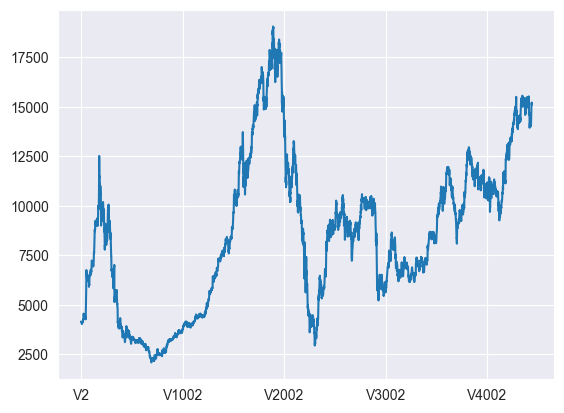

In [121]:
ts.plot()

In [129]:
count_shapes(ts, 5)

[250,
 253,
 253,
 267,
 255,
 279,
 261,
 295,
 253,
 266,
 281,
 289,
 264,
 292,
 295,
 348]

In [119]:
double_chi2_test(ts, 0.9)

False

In [130]:
aaa.to_csv("../src/metrics&entropy_M4.csv")